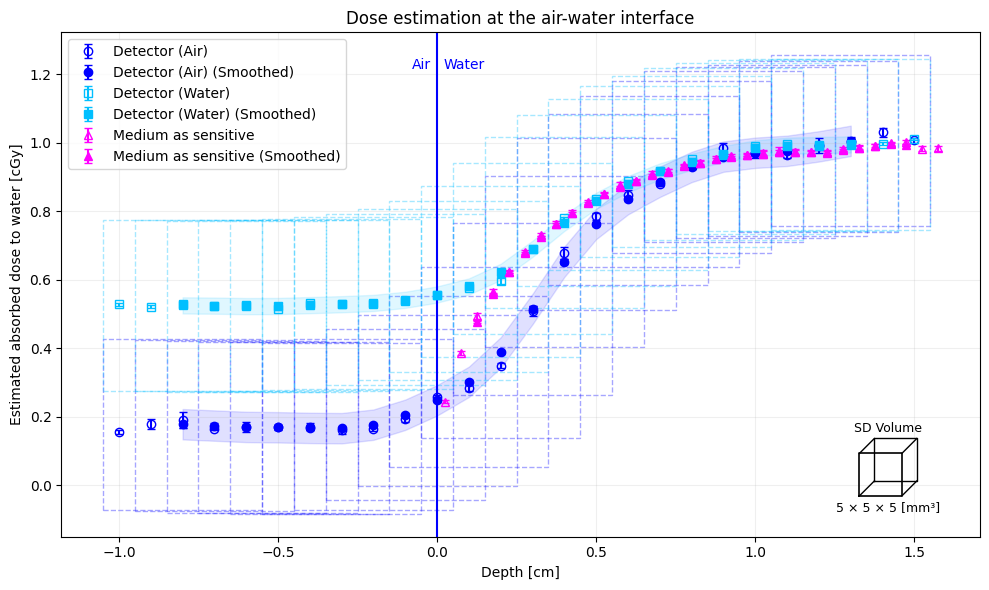

Counts:
Original points series 1 : 26
Smoothed series 1        : 22
Original points series 2 : 26
Smoothed series 2        : 22
Original points series 3 : 32
Smoothed series 3        : 28
Binomial kernel          : [0.0625 0.25   0.375  0.25   0.0625]

Smoothed binomial data series 1:
x=-0.800, y=0.177841, yerr=0.009679
x=-0.700, y=0.173835, yerr=0.007050
x=-0.600, y=0.169876, yerr=0.005845
x=-0.500, y=0.168838, yerr=0.005268
x=-0.400, y=0.166984, yerr=0.005190
x=-0.300, y=0.166121, yerr=0.004815
x=-0.200, y=0.176483, yerr=0.004313
x=-0.100, y=0.205484, yerr=0.004517
x= 0.000, y=0.247634, yerr=0.004367
x= 0.100, y=0.301704, yerr=0.004582
x= 0.200, y=0.387517, yerr=0.005444
x= 0.300, y=0.514536, yerr=0.007342
x= 0.400, y=0.652694, yerr=0.007766
x= 0.500, y=0.762870, yerr=0.006558
x= 0.600, y=0.835176, yerr=0.005887
x= 0.700, y=0.885931, yerr=0.005002
x= 0.800, y=0.929309, yerr=0.005882
x= 0.900, y=0.959564, yerr=0.007303
x= 1.000, y=0.970813, yerr=0.007016
x= 1.100, y=0.976486, yerr=0.0

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

DATA_DIR_CANDIDATES = [
    Path.cwd() / "data",
    Path.cwd() / "dose_at_interface" / "data",
    Path.cwd() / "analysis" / "dosimetry_invivo" / "dose_at_interface" / "data",
]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find the data directory. Run the notebook from analysis/dosimetry_invivo/dose_at_interface, analysis/dosimetry_invivo, or the repository root."
    )

def binomial_smooth_5(x, y, yerr):
    if not (len(x) == len(y) == len(yerr)):
        raise ValueError("x, y y yerr must have the same length")
    if len(x) < 5:
        raise ValueError("At least 5 points are required")
    weights = np.array([1, 4, 6, 4, 1], dtype=float) / 16.0
    x_out = x[2:-2].copy()
    y_out = (
        weights[0] * y[:-4]
        + weights[1] * y[1:-3]
        + weights[2] * y[2:-2]
        + weights[3] * y[3:-1]
        + weights[4] * y[4:]
    )
    yerr_out = np.sqrt(
        (weights[0] * yerr[:-4]) ** 2
        + (weights[1] * yerr[1:-3]) ** 2
        + (weights[2] * yerr[2:-2]) ** 2
        + (weights[3] * yerr[3:-1]) ** 2
        + (weights[4] * yerr[4:]) ** 2
    )
    return x_out, y_out, yerr_out, weights

_df = pd.read_csv(DATA_DIR / "detector_air.csv")
_df2 = pd.read_csv(DATA_DIR / "detector_water.csv")
_df3 = pd.read_csv(DATA_DIR / "medium_as_sensitive.csv")

required_cols_1 = ["cube_z_cm", "depth_cm", "mean_estimated_total_absorbed_dose_cGy", "err_cGy"]
required_cols_2 = ["cube_z_cm", "depth_cm", "mean_estimated_total_absorbed_dose_cGy", "err_cGy"]
required_cols_3 = ["iZ", "mean_dose_cGy", "err_dose_cGy"]
for col in required_cols_1:
    assert col in _df.columns, f"Missing required column in series 1: {col}"
for col in required_cols_2:
    assert col in _df2.columns, f"Missing required column in series 2: {col}"
for col in required_cols_3:
    assert col in _df3.columns, f"Missing required column in series 3: {col}"

assert len(_df) == 26
assert len(_df2) == 26
assert len(_df3) == 32
assert _df["depth_cm"].is_monotonic_increasing
assert _df2["depth_cm"].is_monotonic_increasing

_test_x = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
_test_y = np.array([10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0])
_test_e = np.array([1.0, 1.0, 2.0, 2.0, 3.0, 3.0, 4.0])
_tx, _ty, _te, _tw = binomial_smooth_5(_test_x, _test_y, _test_e)
assert np.allclose(_tw, np.array([1, 4, 6, 4, 1]) / 16.0)
assert np.allclose(_tx, np.array([2.0, 3.0, 4.0]))
assert np.allclose(_ty, np.array([30.0, 40.0, 50.0]))
assert len(_te) == 3

square_side = 0.5
assert np.isclose(square_side, 0.5)

# Series 1
x = _df["depth_cm"].to_numpy()
y = _df["mean_estimated_total_absorbed_dose_cGy"].to_numpy()
yerr = _df["err_cGy"].to_numpy()
xb, yb, eb, weights = binomial_smooth_5(x, y, yerr)
residuals = y[2:-2] - yb
sigma_res = np.std(residuals, ddof=1)

# Series 2
x2 = _df2["depth_cm"].to_numpy()
y2 = _df2["mean_estimated_total_absorbed_dose_cGy"].to_numpy()
yerr2 = _df2["err_cGy"].to_numpy()
xb2, yb2, eb2, weights2 = binomial_smooth_5(x2, y2, yerr2)
residuals2 = y2[2:-2] - yb2
sigma_res2 = np.std(residuals2, ddof=1)

# Medium as sensitive: shift left by half bin to center the points
# x = 16 mm - iZ*0.5 mm - 0.25 mm, converted to cm
_df3["depth_cm"] = (16.0 - _df3["iZ"] * 0.5 - 0.25) / 10.0
_df3 = _df3.sort_values("depth_cm").reset_index(drop=True)
x3 = _df3["depth_cm"].to_numpy()
y3 = _df3["mean_dose_cGy"].to_numpy()
err3 = _df3["err_dose_cGy"].to_numpy()
xb3, yb3, eb3, weights3 = binomial_smooth_5(x3, y3, err3)
assert np.allclose(weights3, weights)

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(x, y, yerr=yerr, fmt="o", capsize=3, color="blue", ecolor="blue", mfc="none", mec="blue", label="Detector (Air)")
ax.fill_between(xb, yb - 3 * sigma_res, yb + 3 * sigma_res, color="blue", alpha=0.12, label="_nolegend_")
ax.errorbar(xb, yb, yerr=eb, fmt="o", capsize=3, color="blue", ecolor="blue", mfc="blue", mec="blue", label="Detector (Air) (Smoothed)")
for xi, yi in zip(xb, yb):
    ax.add_patch(Rectangle((xi - square_side / 2, yi - square_side / 2), square_side, square_side, fill=False, edgecolor="blue", linewidth=1.0, linestyle="--", alpha=0.35))

ax.errorbar(x2, y2, yerr=yerr2, fmt="s", capsize=3, color="deepskyblue", ecolor="deepskyblue", mfc="none", mec="deepskyblue", label="Detector (Water)")
ax.fill_between(xb2, yb2 - 3 * sigma_res2, yb2 + 3 * sigma_res2, color="deepskyblue", alpha=0.12, label="_nolegend_")
ax.errorbar(xb2, yb2, yerr=eb2, fmt="s", capsize=3, color="deepskyblue", ecolor="deepskyblue", mfc="deepskyblue", mec="deepskyblue", label="Detector (Water) (Smoothed)")
for xi, yi in zip(xb2, yb2):
    ax.add_patch(Rectangle((xi - square_side / 2, yi - square_side / 2), square_side, square_side, fill=False, edgecolor="deepskyblue", linewidth=1.0, linestyle="--", alpha=0.35))

ax.errorbar(x3, y3, yerr=err3, fmt="^", capsize=3, color="magenta", ecolor="magenta", mfc="none", mec="magenta", label="Medium as sensitive")
ax.errorbar(xb3, yb3, yerr=eb3, fmt="^", capsize=3, color="magenta", ecolor="magenta", mfc="magenta", mec="magenta", label="Medium as sensitive (Smoothed)")

ax.set_xlabel("Depth [cm]")
ax.set_ylabel("Estimated absorbed dose to water [cGy]")
ax.set_title("Dose estimation at the air-water interface")
ax.grid(True, alpha=0.2)
ax.axvline(0, color="blue", linestyle="-", linewidth=1.5)
ymin, ymax = ax.get_ylim()
y_text = ymax - 0.05 * (ymax - ymin)
ax.text(-0.02, y_text, "Air", ha="right", va="top", color="blue")
ax.text(0.02, y_text, "Water", ha="left", va="top", color="blue")

cube_ax = ax.inset_axes([0.82, 0.06, 0.16, 0.16])
cube_ax.set_aspect('equal')
cube_ax.axis('off')
s = 1.0
dx = 0.35
dy = 0.35
cube_ax.plot([0, s, s, 0, 0], [0, 0, s, s, 0], color='black', linewidth=1.2)
cube_ax.plot([dx, s+dx, s+dx, dx, dx], [dy, dy, s+dy, s+dy, dy], color='black', linewidth=1.0)
cube_ax.plot([0, dx], [0, dy], color='black', linewidth=1.0)
cube_ax.plot([s, s+dx], [0, dy], color='black', linewidth=1.0)
cube_ax.plot([0, dx], [s, s+dy], color='black', linewidth=1.0)
cube_ax.plot([s, s+dx], [s, s+dy], color='black', linewidth=1.0)
cube_ax.set_xlim(-0.05, s + dx + 0.05)
cube_ax.set_ylim(-0.25, s + dy + 0.30)
cube_ax.text((s + dx) / 2, s + dy + 0.08, "SD Volume", ha="center", va="bottom", fontsize=9)
cube_ax.text((s + dx) / 2, -0.12, "5 × 5 × 5 [mm³]", ha="center", va="top", fontsize=9)

ax.legend()
plt.tight_layout()
plt.show()

print("Counts:")
print("Original points series 1 :", len(x))
print("Smoothed series 1        :", len(xb))
print("Original points series 2 :", len(x2))
print("Smoothed series 2        :", len(xb2))
print("Original points series 3 :", len(x3))
print("Smoothed series 3        :", len(xb3))
print("Binomial kernel          :", weights)

print("\nSmoothed binomial data series 1:")
for xi, yi, ei in zip(xb, yb, eb):
    print(f"x={xi:6.3f}, y={yi:8.6f}, yerr={ei:8.6f}")

print("\nSmoothed binomial data series 2:")
for xi, yi, ei in zip(xb2, yb2, eb2):
    print(f"x={xi:6.3f}, y={yi:8.6f}, yerr={ei:8.6f}")

print("\nSmoothed binomial data series 3:")
for xi, yi, ei in zip(xb3, yb3, eb3):
    print(f"x={xi:6.3f}, y={yi:8.6f}, yerr={ei:8.6f}")
